# Phase 1 — Tabular data: storytelling from tables (Solution)

**Mục tiêu:** chọn 2–3 hình có *thứ tự logic*: context → comparison → takeaway. Mỗi hình map rõ một cột/tổ hợp cột từ bảng gốc.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError(
        "Cannot locate data/gapminder.csv from current working directory"
    )

root = resolve_repo_root()


sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "gapminder.csv")
df.head()


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## Fig 1 — Trend theo thời gian (aggregate từ bảng dài)

Nhóm theo `year` và `continent` để có đường trend rõ.


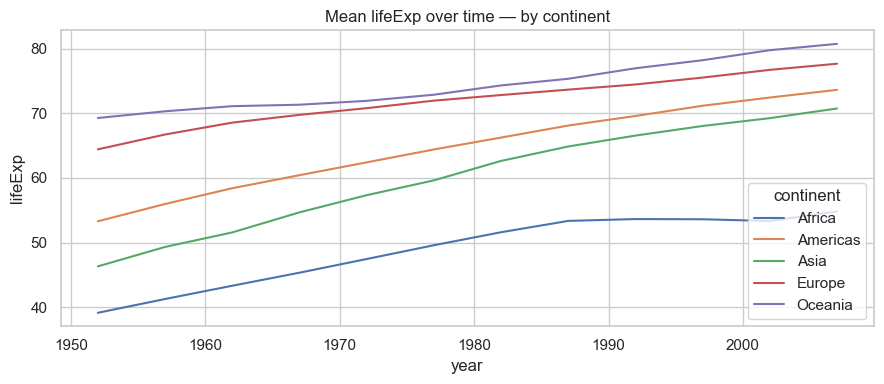

In [2]:
trend = df.groupby(["year", "continent"], as_index=False)["lifeExp"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=trend, x="year", y="lifeExp", hue="continent", ax=ax)
ax.set_title("Mean lifeExp over time — by continent")
plt.tight_layout()
plt.show()


## Fig 2 — Snapshot 2007: ai “outlier richness”?

Chấm các quốc gia trong scatter; annotate một vài điển hình.


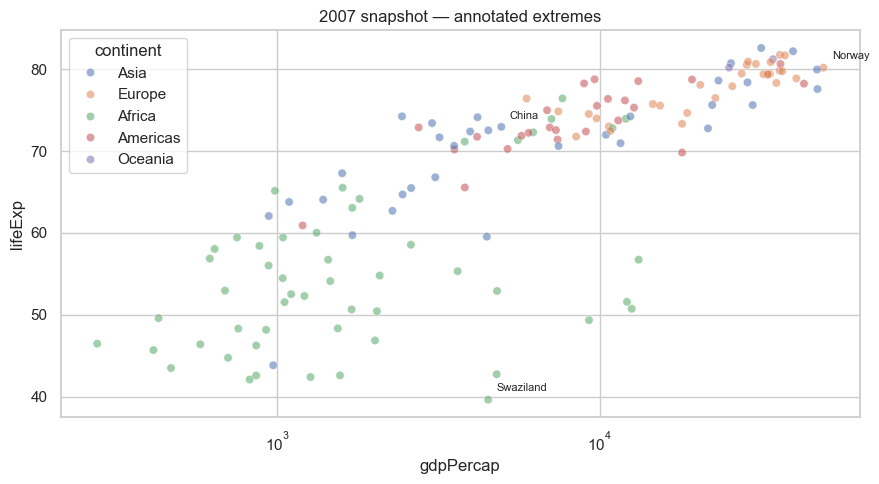

In [3]:
d2007 = df[df["year"] == 2007].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=d2007, x="gdpPercap", y="lifeExp", hue="continent", alpha=0.55, ax=ax)
ax.set_xscale("log")

# annotate a few extremes
annotate = pd.concat([
    d2007.nlargest(1, "gdpPercap"),
    d2007.nsmallest(1, "lifeExp"),
    d2007.nlargest(1, "pop"),
])
for _, row in annotate.iterrows():
    ax.annotate(
        row["country"],
        (row["gdpPercap"], row["lifeExp"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("2007 snapshot — annotated extremes")
plt.tight_layout()
plt.show()


## Fig 3 — Kiểm chứng theo nhóm (strip + jitter để tránh overplot nhẹ)

Dùng khi có quá nhiều điểm scatter overlap trong một continent.


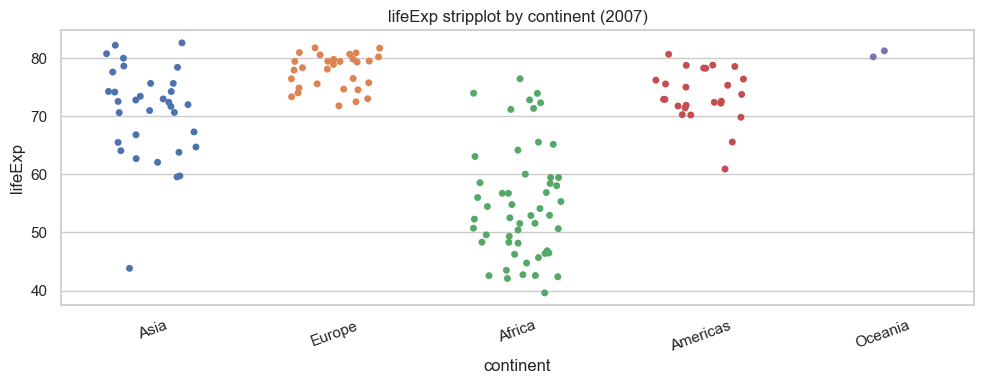

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.stripplot(data=d2007, x="continent", y="lifeExp", hue="continent", dodge=False, jitter=0.25, legend=False)
ax.tick_params(axis="x", rotation=20)
ax.set_title("lifeExp stripplot by continent (2007)")
plt.tight_layout()
plt.show()


## Reflection / Story takeaway

Viết 5–8 câu: khác biệt giữa *quan sát trên đường aggregate theo continent* và *quan sát từng dòng country* trong snapshot 2007; nêu 1 caveat khi annotate điểm cực trị có pop lớn.


## Legacy add-on (tach tu `legacy_chapter_aligned/solution.executed.ipynb`)

Phan bo sung nay duoc ghep lai tu notebook cu de giu noi dung theo giao trinh, nhung da map vao track tabular hien tai.

### Imported section: ## 8) Visualizing trends
Mục tiêu: line chart theo thời gian.

## 8) Visualizing trends
Mục tiêu: line chart theo thời gian.

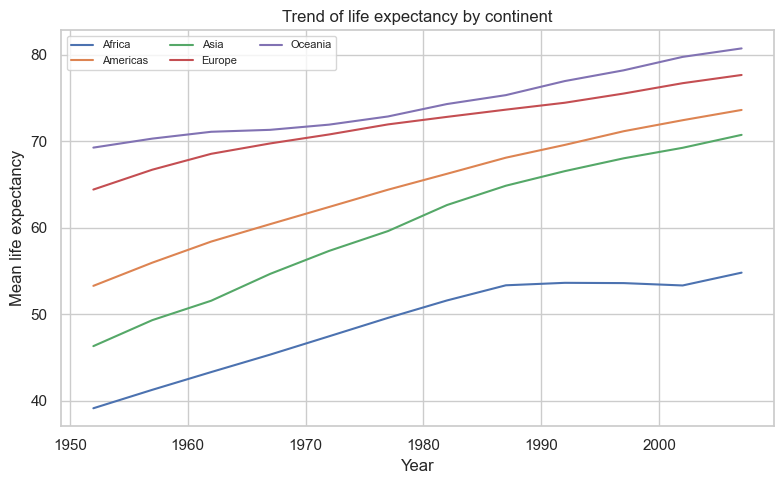

In [5]:
trend = df.groupby(["year","continent"], as_index=False).agg(lifeExp=("lifeExp","mean"))
plt.figure(figsize=(8,5))
for c, g in trend.groupby("continent"):
    plt.plot(g["year"], g["lifeExp"], label=c)
plt.title("Trend of life expectancy by continent")
plt.xlabel("Year"); plt.ylabel("Mean life expectancy")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

### Imported section: ## 9) Visualizing uncertainty
Mục tiêu: hiển thị CI cho trend.

## 9) Visualizing uncertainty
Mục tiêu: hiển thị CI cho trend.

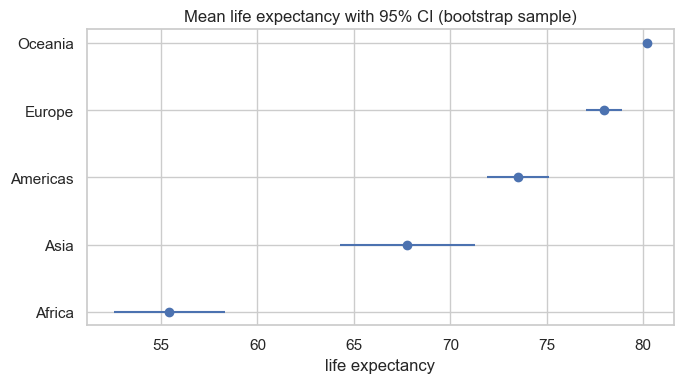

,continent,mean,ci95
0,Africa,55.419596,2.881695
2,Asia,67.765478,3.486758
1,Americas,73.498629,1.591938
3,Europe,77.956486,0.952134
4,Oceania,80.204000,0.000000


In [6]:
sample = d2007.sample(frac=1.0, replace=True, random_state=42)
summary = sample.groupby("continent")["lifeExp"].agg(["mean","std","count"]).reset_index()
summary["se"] = summary["std"]/np.sqrt(summary["count"])
summary["ci95"] = 1.96*summary["se"]
summary = summary.sort_values("mean")

plt.figure(figsize=(7,4))
plt.errorbar(summary["mean"], summary["continent"], xerr=summary["ci95"], fmt="o")
plt.title("Mean life expectancy with 95% CI (bootstrap sample)")
plt.xlabel("life expectancy")
plt.tight_layout(); plt.show()
summary[["continent","mean","ci95"]]

### Imported section: ## Reflection
- Nêu rõ khi nào dùng từng nhóm biểu đồ ở trên.
- Chỉ ra 2 lỗi diễn giải dễ gặp (pie với nhiều nhóm, line cho categorical, v.v.).
- Kết luận: với data bảng, chọn chart theo task (amount/distribution/proportion/association/trend/uncertainty), không chọn theo thói quen.

## Reflection
- Nêu rõ khi nào dùng từng nhóm biểu đồ ở trên.
- Chỉ ra 2 lỗi diễn giải dễ gặp (pie với nhiều nhóm, line cho categorical, v.v.).
- Kết luận: với data bảng, chọn chart theo task (amount/distribution/proportion/association/trend/uncertainty), không chọn theo thói quen.